# Bouncing ball

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bernardorivas/hybrid_boxmap/blob/main/notebooks/bouncing_ball.ipynb)

The system is given by

$$\dot h=v,\qquad \dot v=-g,$$

with guard and reset

$$G=\{(0,v): v\leq 0\},\qquad r(0,v)=(0,-cv),$$

where $g=9.81$ and $c=0.8$.

In [1]:
import os, sys

if "google.colab" in sys.modules:
    if not os.path.isdir("/content/hybrid_boxmap"):
        !git clone -q --depth 1 https://github.com/bernardorivas/hybrid_boxmap.git /content/hybrid_boxmap
        !which dot > /dev/null || (apt-get -qq update && apt-get -qq install -y graphviz) > /dev/null
        !pip install -q "cmgdb==1.3.3+fork.5" --find-links https://github.com/bernardorivas/CMGDB/releases/expanded_assets/v1.3.3%2Bfork.5
    os.chdir("/content/hybrid_boxmap")
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 47.2 MB/s eta 0:00:00


## Phase portrait

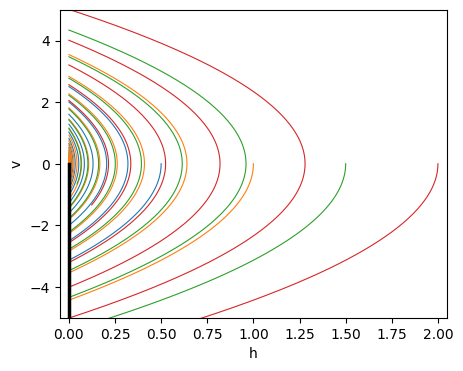

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from hybrid_dynamics.examples.paper_examples import paper_problem

problem = paper_problem("bouncing-ball")

fig, ax = plt.subplots(figsize=(5, 4))
for state in [(0.5, 0.0), (1.0, 0.0), (1.5, 0.0), (2.0, 0.0)]:
    trajectory = problem.system.simulate(np.array(state, float), (0.0, 4.0), max_jumps=30, max_step=0.005)
    color = None
    for segment in trajectory.segments:
        line, = ax.plot(*np.asarray(segment.state_values).T, lw=0.8, color=color)
        color = line.get_color()
ax.plot([0, 0], [-5, 0], color="k", lw=2.5)  # guard
ax.set(xlim=(-0.05, 2.05), ylim=(-5, 5), xlabel="h", ylabel="v")
plt.show()

## Morse sets

Computed with $\tau=0.5$ on a $2^{10}\times2^{10}$ grid of $R=[0,2]\times[-5,5]$.

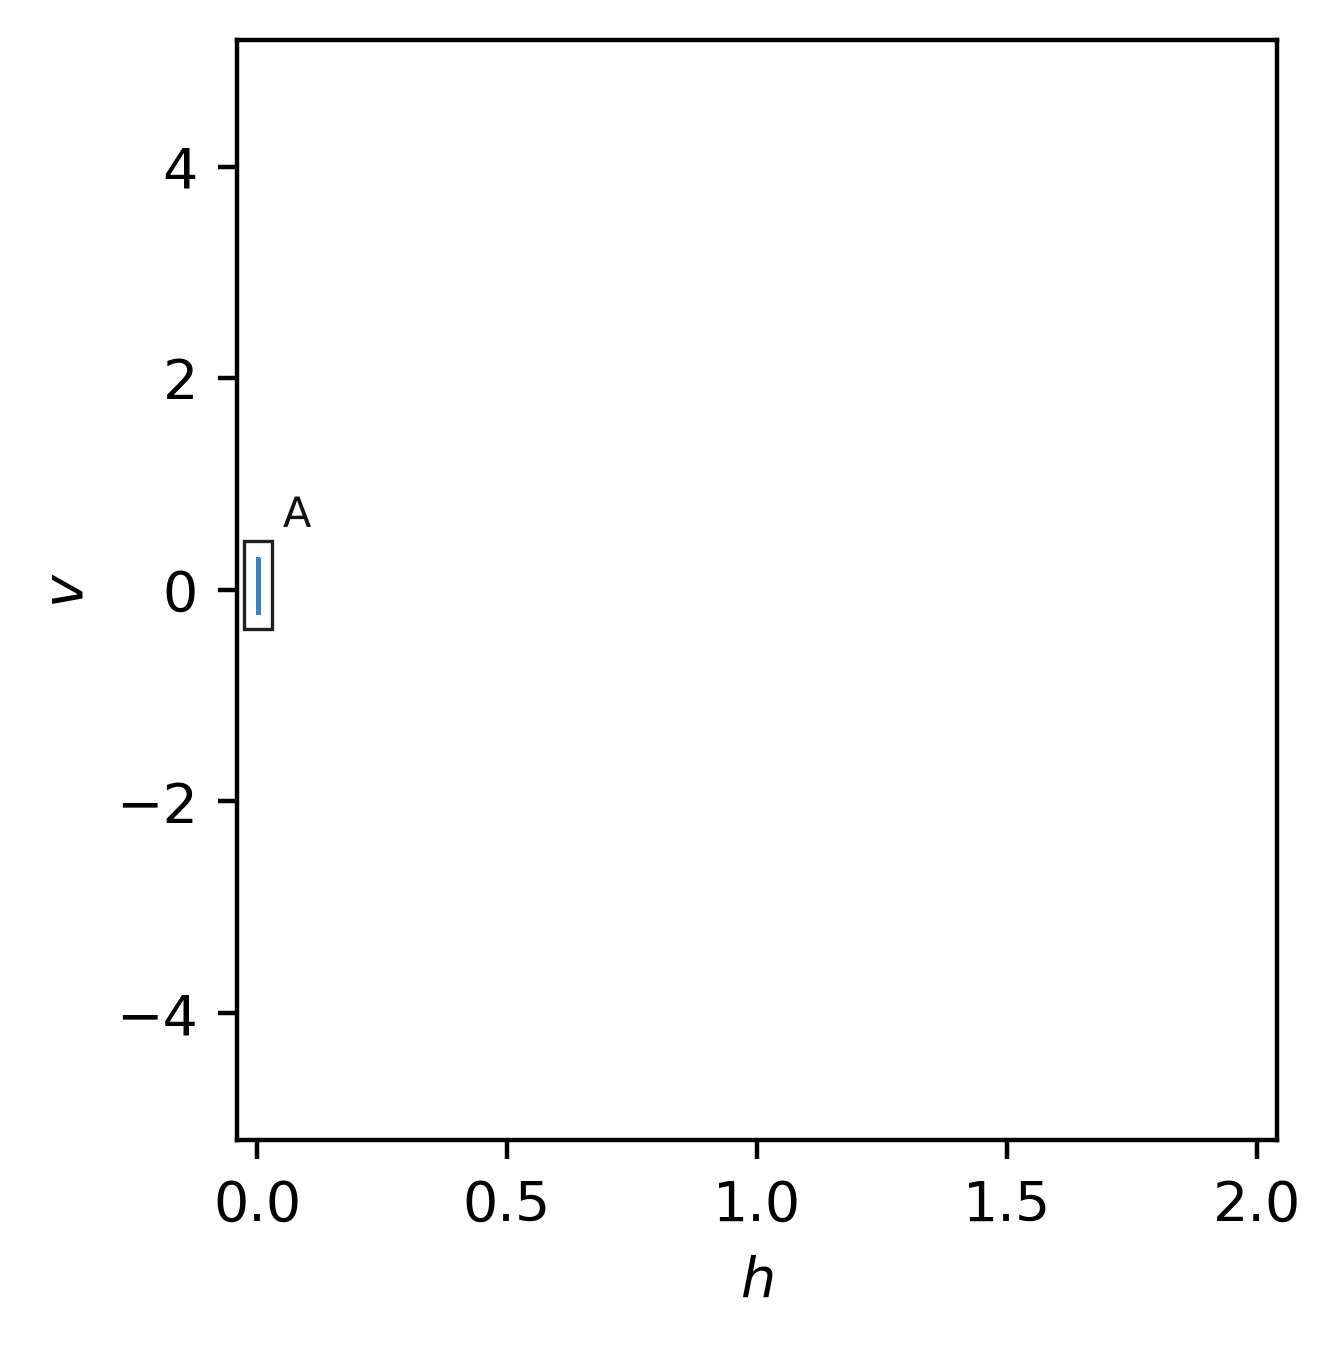

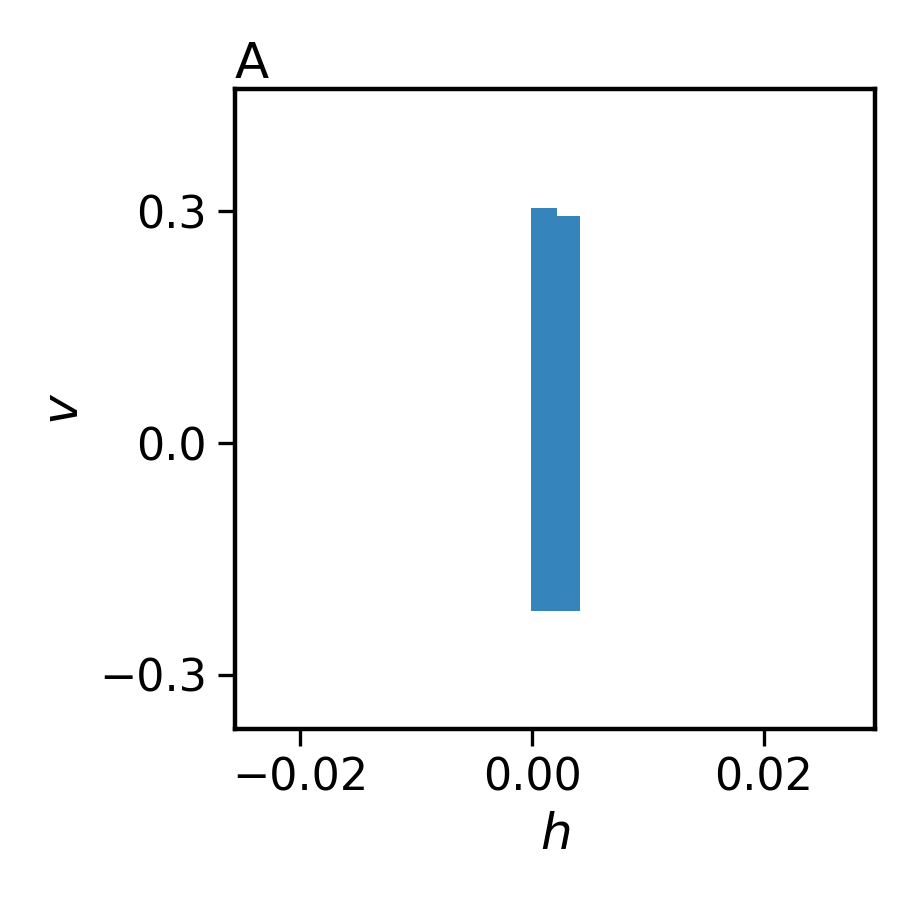

In [3]:
from functools import partial
from IPython.display import Image, display
from hybrid_dynamics.src.suspension_grid import build_suspension_grid
from hybrid_dynamics.src.suspension_grid_relation import (
    compute_suspension_grid_relation,
    compute_suspension_morse_graph,
)
from hybrid_dynamics.src.suspension_grid_conley import compute_suspension_grid_conley_indices
from hybrid_dynamics.examples.paper_figures import write_paper_figures

tau, level, level_offset = 0.5, 6, 4
factory = partial(paper_problem, "bouncing-ball", tau=tau, level_offset=level_offset)
problem = factory()
workers = os.cpu_count()

grid = build_suspension_grid(problem.window, problem.guard, level=level)
relation = compute_suspension_grid_relation(
    grid, problem, gap_refinement_depth=14, workers=workers, problem_factory=factory
)
morse_graph = compute_suspension_morse_graph(relation)
conley = compute_suspension_grid_conley_indices(
    relation, morse_graph.morse_sets, workers=workers, problem_factory=factory, index_map="auto"
)

os.makedirs("output", exist_ok=True)
stem = "output/bouncing-ball"
write_paper_figures(
    grid, morse_graph.morse_sets, morse_graph.edges, [index.to_dict() for index in conley],
    example="bouncing-ball", tau=tau, level=level, output_stem=stem, audit_path=stem + ".json",
    variants=("all", "nontrivial"),
)

for panel in ["nontrivial-base", "nontrivial-zoom-A"]:
    display(Image(f"{stem}-{panel}.png", width=420))

## Conley–Morse graph

Labels are the dimensions of the Conley index in degrees 0, 1, 2. Morse sets with trivial Conley index are gray.

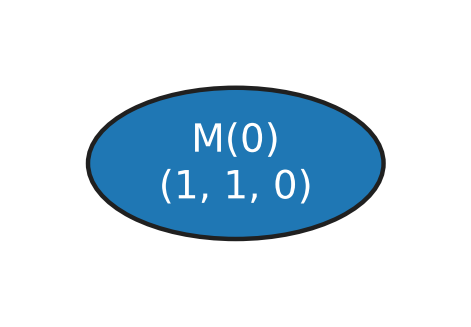

In [4]:
for panel in ["graph"]:
    display(Image(f"{stem}-{panel}.png", width=420))